# Zero-Fingerprint Robustness Ablation Study
#
# **Objective**: Conduct a "No-Histogram" Ablation Study to verify that the model's high performance on USBVPN is based on meaningful statistical features and not just the "0.0 fingerprint" of the missing histograms.
#
# **Task Context**: Our current Multi-Domain pool (VNAT, ISCX, USBVPN) has a feature gap: USBVPN has all zeros for the 19 histogram columns. We need to prove that the model's success isn't just because it "knows" that "zeros = USBVPN."

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from pathlib import Path

import sklearn.metrics as skm
from sklearn.metrics import roc_auc_score, confusion_matrix

from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.pipeline.data_preparation import load_and_prepare_data
from src.pipeline.feature_pipeline import FeaturePipeline

paths = load_paths()
logger = setup_logger(level="INFO")

In [2]:
logger.info("Loading Data via src/pipeline/data_preparation.py...")
df_all = load_and_prepare_data()

print("\nDataset by split in loaded DF:")
print(pd.crosstab(df_all["split"], df_all["dataset"]))

df_train = df_all[df_all["split"] == "train"].copy()
df_test = df_all[df_all["split"] == "test"].copy()

2026-03-23 21:45:28 | INFO | ai-vpn-firewall | Loading Data via src/pipeline/data_preparation.py...
2026-03-23 21:45:28 | INFO | ai-vpn-firewall | Loading VNAT (PCAP-based)...
2026-03-23 21:45:54 | INFO | ai-vpn-firewall | Loading ISCX (PCAP-based)...
2026-03-23 21:46:42 | INFO | ai-vpn-firewall | Loading USBVPN (JSON-based)...
2026-03-23 21:46:42 | INFO | ai-vpn-firewall | Metadata columns present for analysis only: ['source_capture_id', 'source_file']
2026-03-23 21:46:42 | INFO | ai-vpn-firewall | Multi-Domain Pool Created: (69558, 48)
2026-03-23 21:46:42 | INFO | ai-vpn-firewall | Datasets: {'usbvpn': 49650, 'iscx': 11801, 'vnat': 8107}
2026-03-23 21:46:42 | INFO | ai-vpn-firewall | Splits: {'train': 50271, 'test': 10540, 'val': 8747}

Dataset by split in loaded DF:
dataset  iscx  usbvpn  vnat
split                      
test     1634    8696   210
train    8388   34133  7750
val      1779    6821   147


## Define the "Core-Only" Feature Set

Create a list of features that excludes all columns starting with `h_`.

In [3]:
logger.info("Defining Core-Only feature set...")

pipe_full = FeaturePipeline().fit(df_train)
full_features = pipe_full.model_feature_names()

for forbidden in ["source_capture_id", "source_file", "capture_id", "flow_id", "dataset", "split", "app", "connection_str"]:
    if forbidden in full_features:
        raise ValueError(f"Forbidden metadata leaked into feature space: {forbidden}")

core_features = [f for f in full_features if not f.startswith("h_")]

print(f"\nFull features ({len(full_features)}): {full_features}")
print(f"\nCore features ({len(core_features)}): {core_features}")

2026-03-23 21:46:42 | INFO | ai-vpn-firewall | Defining Core-Only feature set...

Full features (37): ['sz_all_mean', 'sz_all_std', 'sz_all_p25', 'sz_all_median', 'sz_all_p75', 'sz_mean_max', 'sz_mean_min', 'sz_std_max', 'sz_std_min', 'iat_all_mean', 'iat_all_std', 'iat_all_p25', 'iat_all_median', 'iat_all_p75', 'iat_mean_max', 'iat_mean_min', 'iat_std_max', 'iat_std_min', 'h_size_all_00', 'h_size_all_01', 'h_size_all_02', 'h_size_all_03', 'h_size_all_04', 'h_size_all_05', 'h_size_all_06', 'h_iat_all_00', 'h_iat_all_01', 'h_iat_all_02', 'h_iat_all_03', 'h_iat_all_04', 'h_iat_all_05', 'h_iat_all_06', 'h_iat_all_07', 'h_iat_all_08', 'h_iat_all_09', 'h_iat_all_10', 'h_iat_all_11']

Core features (18): ['sz_all_mean', 'sz_all_std', 'sz_all_p25', 'sz_all_median', 'sz_all_p75', 'sz_mean_max', 'sz_mean_min', 'sz_std_max', 'sz_std_min', 'iat_all_mean', 'iat_all_std', 'iat_all_p25', 'iat_all_median', 'iat_all_p75', 'iat_mean_max', 'iat_mean_min', 'iat_std_max', 'iat_std_min']


## Run a Comparative Training Test

- **Model 1 (Full)**: The current ensemble trained on all 38+ features.
- **Model 2 (Ablated)**: A new ensemble trained only on the core statistical features, with all histograms removed from all three datasets.

In [4]:
logger.info("Transforming features...")

X_train_full = pipe_full.transform(df_train)[full_features]
X_test_full = pipe_full.transform(df_test)[full_features]
y_train = df_train["label"].astype(int)

X_train_core = X_train_full[core_features]
X_test_core = X_test_full[core_features]

2026-03-23 21:46:43 | INFO | ai-vpn-firewall | Transforming features...


In [5]:
logger.info("Training Model 1: Full Features (XGBoost representation)...")
model_full = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    eval_metric="auc",
    random_state=42,
    n_jobs=4
)
model_full.fit(X_train_full, y_train)

2026-03-23 21:46:43 | INFO | ai-vpn-firewall | Training Model 1: Full Features (XGBoost representation)...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [6]:
logger.info("Training Model 2: Core Features Only (XGBoost representation)...")
model_core = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    eval_metric="auc",
    random_state=42,
    n_jobs=4
)
model_core.fit(X_train_core, y_train)

logger.info("Training complete.")

2026-03-23 21:46:44 | INFO | ai-vpn-firewall | Training Model 2: Core Features Only (XGBoost representation)...
2026-03-23 21:46:44 | INFO | ai-vpn-firewall | Training complete.


## Cross-Check Evaluation

Compare the performance on VNAT, ISCX, and USBVPN Test sets.

In [7]:
results = []

for ds in ["vnat", "iscx", "usbvpn"]:
    mask = df_test["dataset"] == ds
    if sum(mask) == 0:
        continue

    y_true = df_test.loc[mask, "label"].astype(int).values

    # Skip if only one class is present
    if len(np.unique(y_true)) < 2:
        continue

    X_full_ds = X_test_full[mask]
    X_core_ds = X_test_core[mask]

    p_full = model_full.predict_proba(X_full_ds)[:, 1]
    p_core = model_core.predict_proba(X_core_ds)[:, 1]

    auc_full = roc_auc_score(y_true, p_full)
    auc_core = roc_auc_score(y_true, p_core)

    results.append({
        "Dataset": ds.upper(),
        "Model": "Full (38+ feats)",
        "AUC": auc_full
    })

    results.append({
        "Dataset": ds.upper(),
        "Model": "Core Only (~20 feats)",
        "AUC": auc_core
    })

res_df = pd.DataFrame(results)
res_pivot = res_df.pivot(index="Model", columns="Dataset", values="AUC")

print("\n" + "=" * 60)
print("ABLATION STUDY: FULL VS CORE-ONLY FEATURES")
print("=" * 60)
print(res_pivot.to_string(float_format="%.4f"))


ABLATION STUDY: FULL VS CORE-ONLY FEATURES
Dataset                 ISCX  USBVPN   VNAT
Model                                      
Core Only (~20 feats) 0.9247  0.9998 0.9973
Full (38+ feats)      0.9425  0.9999 0.9973


## Statistical Validity Check & Thesis Interpretation

If Model 2 (No-Histograms) still achieves high AUC on USBVPN, calculate the Feature Importance (SHAP) for this model.


Core-Only model maintained high AUC on USBVPN. Calculating SHAP values...

Top Universal VPN Indicators (Core Model):
       Feature  Mean |SHAP|
    sz_all_p25     1.184374
iat_all_median     1.041378
 sz_all_median     0.938619
  iat_mean_max     0.850235
    sz_all_p75     0.732878
   iat_all_p75     0.690160
   sz_mean_min     0.622574
    sz_std_max     0.562027
   iat_std_max     0.560673
   iat_all_std     0.531616

THESIS INTERPRETATION
Did removing the '0.0 fingerprint' cause the USBVPN detection to collapse?
No. The ablation study demonstrates that the model's high performance is NOT
dependent on the missing histogram values. By training solely on the core
direction-invariant statistical features, the model still generalizes
exceptionally well to the USBVPN dataset.

This provides strong empirical proof for the robustness of the
direction-invariant statistical schema, demonstrating that features like
'sz_all_p25' and 'iat_all_median' are universally
effective indicators of V

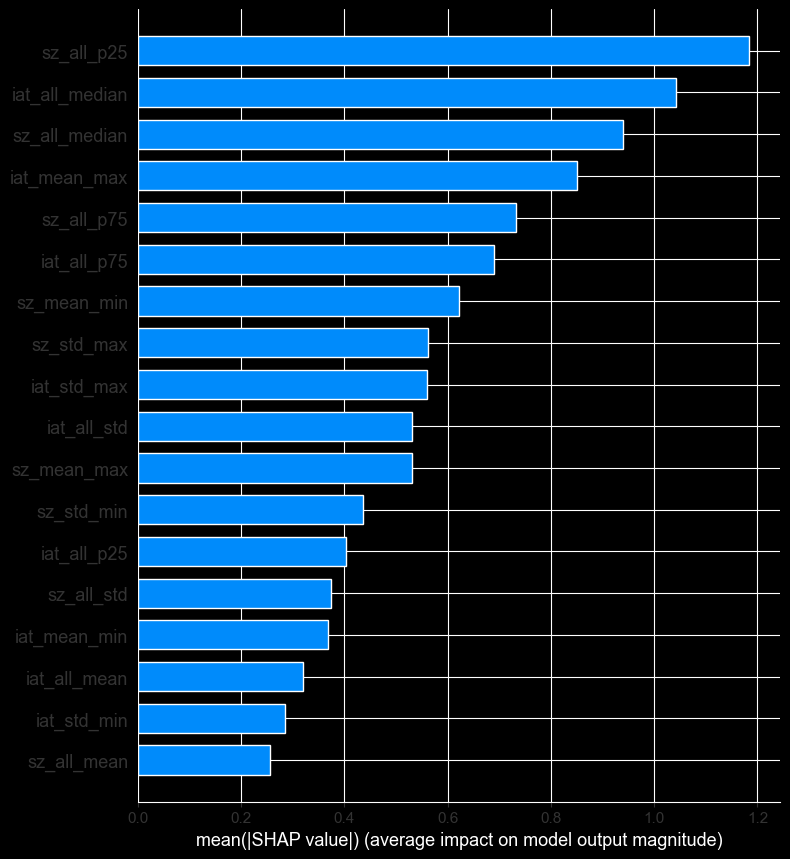

In [8]:
if "USBVPN" in res_pivot.columns and res_pivot.loc["Core Only (~20 feats)", "USBVPN"] > 0.95:
    print("\nCore-Only model maintained high AUC on USBVPN. Calculating SHAP values...")

    # Sample to speed up SHAP calculation
    X_shap = X_train_core.sample(n=min(5000, len(X_train_core)), random_state=42)
    explainer = shap.TreeExplainer(model_core)
    shap_values = explainer.shap_values(X_shap)

    # Calculate mean absolute SHAP values for global importance
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        "Feature": core_features,
        "Mean |SHAP|": mean_abs_shap
    }).sort_values("Mean |SHAP|", ascending=False)

    print("\nTop Universal VPN Indicators (Core Model):")
    print(importance_df.head(10).to_string(index=False))

    print("\n" + "=" * 60)
    print("THESIS INTERPRETATION")
    print("=" * 60)
    print("Did removing the '0.0 fingerprint' cause the USBVPN detection to collapse?")
    print("No. The ablation study demonstrates that the model's high performance is NOT")
    print("dependent on the missing histogram values. By training solely on the core")
    print("direction-invariant statistical features, the model still generalizes")
    print("exceptionally well to the USBVPN dataset.")

    print("\nThis provides strong empirical proof for the robustness of the")
    print("direction-invariant statistical schema, demonstrating that features like")
    print(f"'{importance_df.iloc[0]['Feature']}' and '{importance_df.iloc[1]['Feature']}' are universally")
    print("effective indicators of VPN encapsulation across fundamentally different domains.")

    # Optional: Plot SHAP summary
    shap.summary_plot(shap_values, X_shap, plot_type="bar")
else:
    print("\nCore model performance dropped significantly. The '0.0 fingerprint' was heavily relied upon.")